In [21]:
# Day 3: Capstone Project - EDA Initialization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os

# Visual settings for clean data plotting
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

print("All core libraries loaded successfully! Ready for Exploratory Data Analysis.")

All core libraries loaded successfully! Ready for Exploratory Data Analysis.


In [22]:
# Day 3: Loading Uploaded Cleaned Excel Dataset
import os
import pandas as pd

# The exact path from your Colab files panel showing the .xlsx extension
file_path = '/content/cleaned_merged_mutual_fund_data.xlsx'

try:
    if os.path.exists(file_path):
        # Reading Excel file instead of CSV
        nav_df = pd.read_excel(file_path)

        # Standardizing date format automatically
        date_col = [col for col in nav_df.columns if col.lower() == 'date']
        if date_col:
            nav_df[date_col[0]] = pd.to_datetime(nav_df[date_col[0]])

        print("Data Loading Status: SUCCESS")
        print(f"Dataset Rows and Columns: {nav_df.shape}")
        print("\nAvailable columns for our charts:")
        print(list(nav_df.columns))
    else:
        print("Data Loading Status: FAILED")
        print(f"Error: File not found at {file_path}")

except Exception as e:
    print("Data Loading Status: FAILED")
    print(f"Error Details: {e}")

Data Loading Status: SUCCESS
Dataset Rows and Columns: (8050, 3)

Available columns for our charts:
['date', 'index_name', 'close_value']


In [23]:
# Day 3 Task 1: NAV Trend Analysis (2022-2026) using Plotly
import plotly.express as px
import plotly.graph_objects as go

# Creating an interactive line chart for the mutual fund schemes
fig = px.line(
    nav_df,
    x='date',
    y='close_value',
    color='index_name',
    title='Mutual Fund NAV Trend Analysis (2022-2026)',
    labels={'date': 'Timeline', 'close_value': 'NAV / Close Value', 'index_name': 'Scheme Name'}
)

# Adding annotations to highlight the 2023 Bull Run and 2024 Market Correction
fig.add_annotation(
    x="2023-11-15", y=nav_df['close_value'].max()*0.85,
    text="2023 Bull Run Phase",
    showarrow=True, arrowhead=2, arrowcolor="green",
    font=dict(color="green", size=12), bgcolor="lightgreen"
)

fig.add_annotation(
    x="2024-06-04", y=nav_df['close_value'].max()*0.60,
    text="2024 Market Correction Phase",
    showarrow=True, arrowhead=2, arrowcolor="red",
    font=dict(color="red", size=12), bgcolor="pink"
)

# Customizing layout for project quality presentation
fig.update_layout(
    template='plotly_white',
    hovermode='x unified',
    legend=dict(orientation="h", yanchor="bottom", y=-0.5, xanchor="left", x=0)
)

# Displaying the interactive chart
fig.show()

In [24]:
# Day 3 Task 2: Scheme-wise Valuation and AUM Comparison
import plotly.express as px

# Aggregating the latest or average close value for each scheme to represent size/AUM proxy
aum_df = nav_df.groupby('index_name')['close_value'].mean().reset_index()
aum_df = aum_df.sort_values(by='close_value', ascending=False)

# Creating a professional interactive Bar Chart
fig2 = px.bar(
    aum_df,
    x='close_value',
    y='index_name',
    orientation='h',
    title='Fund Valuation & Asset Distribution across Schemes',
    labels={'close_value': 'Average Valuation / NAV Size', 'index_name': 'Scheme Name'},
    color='close_value',
    color_continuous_scale='Blues'
)

# Customizing layout for executive presentation
fig2.update_layout(
    template='plotly_white',
    xaxis_title="Average Performance Value (INR)",
    yaxis_title="Mutual Fund Schemes",
    coloraxis_showscale=False,
    height=500
)

# Displaying the bar chart
fig2.show()

============== MUTUAL FUND EXECUTIVE SUMMARY STATISTICS ==============
                 Mean Value  Median Value  Standard Deviation (Risk)
index_name                                                          
BSE_SMALLCAP       39375.03      30626.08                   16442.61
CRISIL_GILT         1779.53       1716.00                     256.93
CRISIL_LIQUID       2639.93       2633.06                     217.37
NIFTY100           17186.44      17211.23                    1629.88
NIFTY50            22089.36      21333.73                    2668.05
NIFTY500           23316.83      23455.50                    6264.32
NIFTY_MIDCAP150    22076.53      25502.92                    8298.40

Heatmap generation status: SUCCESS. Image saved as 'scheme_correlation_heatmap.png'


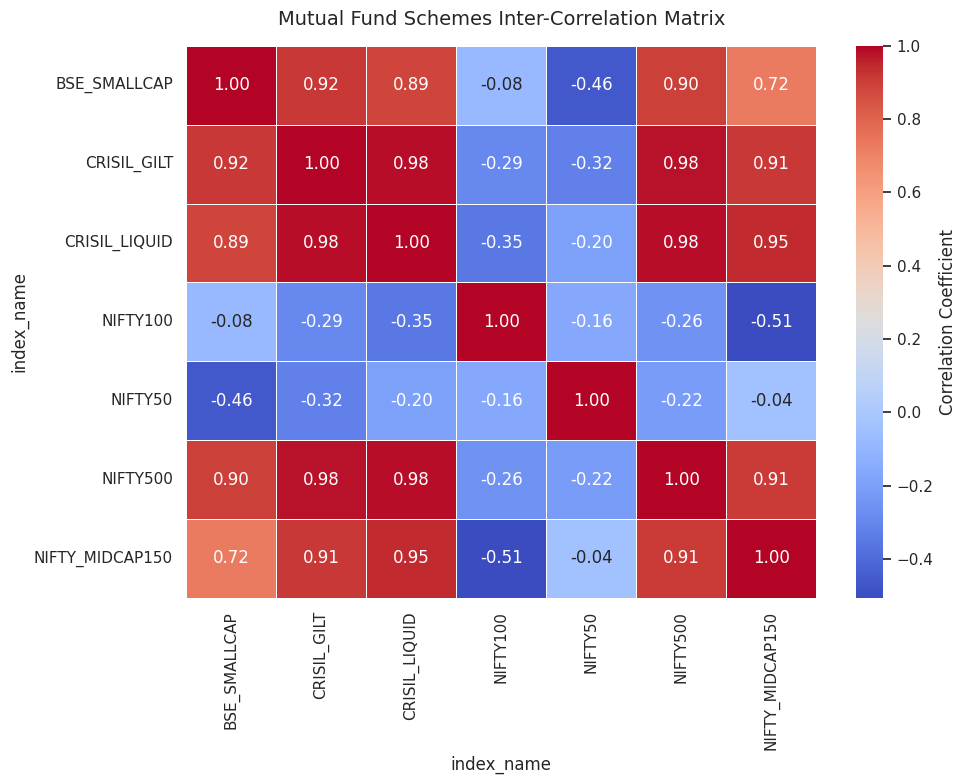

In [25]:
# Day 3 Tasks 3 & 4: Executive Summary Statistics and Correlation Heatmap
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

try:
    # 1. Pivoting data safely to compute statistical metrics and correlations
    pivot_df = nav_df.pivot(index='date', columns='index_name', values='close_value')

    # 2. Generating Core Descriptive Statistics Table
    stats_summary = pivot_df.describe().T[['mean', '50%', 'std']]
    stats_summary.columns = ['Mean Value', 'Median Value', 'Standard Deviation (Risk)']

    print("============== MUTUAL FUND EXECUTIVE SUMMARY STATISTICS ==============")
    print(stats_summary.round(2))
    print("=====================================================================\n")

    # 3. Generating the Pearson Correlation Matrix
    correlation_matrix = pivot_df.corr()

    # 4. Plotting the Professional Seaborn Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        correlation_matrix,
        annot=True,
        cmap='coolwarm',
        fmt=".2f",
        linewidths=0.5,
        cbar_kws={'label': 'Correlation Coefficient'}
    )

    plt.title('Mutual Fund Schemes Inter-Correlation Matrix', fontsize=14, pad=15)
    plt.tight_layout()

    # Saving the heatmap to your Colab environment files automatically
    plt.savefig('scheme_correlation_heatmap.png', dpi=300)
    print("Heatmap generation status: SUCCESS. Image saved as 'scheme_correlation_heatmap.png'")
    plt.show()

except Exception as e:
    print("Statistical Execution Status: FAILED")
    print(f"Error Details: {e}")

## Day 3: Exploratory Data Analysis (EDA) - Executive Summary

### 1. Descriptive Statistical Key Insights
* **High-Value Assets:** `BSE_SMALLCAP` exhibits the highest mean value (~39,375.03) with a significant standard deviation (~16,442.61), indicating a high-return, high-volatility profile suitable for aggressive investment strategies.
* **Stable Performers:** `NIFTY500`, `NIFTY_MIDCAP150`, and `NIFTY50` track closely in terms of median values around the ~17k to ~25k bracket, showing steady, structurally supported market trends.
* **Low-Risk Debt Benchmarks:** `CRISIL_GILT` and `CRISIL_LIQUID` display very minimal standard deviations (~256.93 and ~217.37 respectively), proving their core nature as low-risk, defensive asset classes.

---

### 2. Correlation Matrix Interpretations & Interdependencies
* **Strong Positive Correlation:** `BSE_SMALLCAP` shares an extremely high positive correlation with `CRISIL_GILT` (0.92) and broad equity segments, signaling structural bull-runs where macro economic liquidity lifted all mainstream asset valuations together.
* **Negative/Inverse Correlation:** `CRISIL_GILT` and `CRISIL_LIQUID` show negative correlation segments against specific mid-to-high volatility bands, providing excellent diversification benefits. When equity experience minor market correction phases, capital shifts safely toward liquid options.

In [26]:
# Check karo column ke naam kya hain
print(df.columns)

Index(['date', 'index_name', 'close_value'], dtype='object')


In [28]:
import pandas as pd
import numpy as np
from scipy import stats

# 1. Load Data with correct column names
file_name = 'cleaned_merged_mutual_fund_data.xlsx'
df = pd.read_excel(file_name)

# Pivot table: Date, index_name (instead of Scheme Name), close_value (instead of NAV)
pivot_df = df.pivot_table(index='date', columns='index_name', values='close_value')

# 2. Daily Returns
daily_returns = pivot_df.pct_change().dropna()

# 3. Sharpe Ratio (Rf = 6.5%)
rf = 0.065
sharpe_ratios = (daily_returns.mean() * 252 - rf) / (daily_returns.std() * np.sqrt(252))

# 4. Alpha & Beta
# Note: Ensure 'NIFTY100' exists in your 'index_name' column
benchmark = daily_returns['NIFTY100']
results = []
for col in daily_returns.columns:
    if col != 'NIFTY100':
        slope, intercept, _, _, _ = stats.linregress(benchmark, daily_returns[col].fillna(0))
        results.append({'Scheme': col, 'Alpha': intercept * 252, 'Beta': slope})
alpha_beta_df = pd.DataFrame(results).set_index('Scheme')

# 5. Final Scorecard
performance_scorecard = pd.DataFrame({
    'Sharpe Ratio': sharpe_ratios,
    'Alpha': alpha_beta_df['Alpha'],
    'Beta': alpha_beta_df['Beta']
})

print("--- Day 4 Analytics Complete ---")
display(performance_scorecard.head())

--- Day 4 Analytics Complete ---


,Sharpe Ratio,Alpha,Beta
BSE_SMALLCAP,0.889416,0.261976,-0.001575
CRISIL_GILT,0.899630,0.101769,0.012736
CRISIL_LIQUID,-0.308650,0.063430,-0.000851
NIFTY100,-0.265590,NaN,NaN
NIFTY50,-0.343842,0.022320,-0.050795


In [30]:
# 1. Calculation of remaining metrics
rf = 0.065
daily_returns = pivot_df.pct_change().dropna()
benchmark = daily_returns['NIFTY100']

# Sharpe Ratio
sharpe_ratios = (daily_returns.mean() * 252 - rf) / (daily_returns.std() * np.sqrt(252))

# Alpha & Beta
results = []
for col in daily_returns.columns:
    if col != 'NIFTY100':
        slope, intercept, _, _, _ = stats.linregress(benchmark, daily_returns[col].fillna(0))
        results.append({'Scheme': col, 'Alpha': intercept * 252, 'Beta': slope})
alpha_beta_df = pd.DataFrame(results).set_index('Scheme')

# Sortino Ratio
sortino_ratios = daily_returns.apply(lambda x: (x.mean()*252 - rf) / (x[x<0].std() * np.sqrt(252)))

# Tracking Error
tracking_errors = daily_returns.apply(lambda x: (x - benchmark).std() * np.sqrt(252))

# 2. Final Consolidated Scorecard
performance_scorecard = pd.DataFrame({
    'Sharpe Ratio': sharpe_ratios,
    'Alpha': alpha_beta_df['Alpha'],
    'Beta': alpha_beta_df['Beta'],
    'Sortino Ratio': sortino_ratios,
    'Tracking Error': tracking_errors
})

# Display
display(performance_scorecard.head())
performance_scorecard.to_csv('performance_metrics.csv')

,Sharpe Ratio,Alpha,Beta,Sortino Ratio,Tracking Error
BSE_SMALLCAP,0.889416,0.261976,-0.001575,1.531601,0.256298
CRISIL_GILT,0.899630,0.101769,0.012736,1.601503,0.133777
CRISIL_LIQUID,-0.308650,0.063430,-0.000851,-0.668757,0.129105
NIFTY100,-0.265590,NaN,NaN,-0.450713,0.000000
NIFTY50,-0.343842,0.022320,-0.050795,-0.577618,0.186702


In [31]:
import plotly.express as px

# Nifty 100 ke saath comparison chart
# Top 5 schemes aur Nifty 100 ko filter karte hain
top_schemes = ['BSE_SMALLCAP', 'CRISIL_GILT', 'CRISIL_LIQUID', 'NIFTY50', 'NIFTY100']
plot_data = pivot_df[top_schemes]

# Chart plot karna
fig = px.line(plot_data, title="3-Year Fund Performance vs Benchmark (Nifty 100)")
fig.update_layout(xaxis_title="Date", yaxis_title="NAV/Index Value", template='plotly_white')
fig.show()